# Lab 01: Regresion Lineal Multiple
##Estudiante:
* Delgado Ramos Jorge Luis

In [1]:
# LIBRERÍAS
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Se seleccionó el dataset "Melbourne House Prices", cuyo objetivo es predecir la variable continua Price ($y$) en función de múltiples características ($X$).

In [3]:
# Cargar el dataset
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 01/MELBOURNE_HOUSE_PRICES_LESS.csv'
datos = pd.read_csv(ruta_dataset)

# Verificamos las dimensiones para confirmar las reglas
print(f"Dimensiones del dataset original: m={datos.shape[0]} filas, n={datos.shape[1]} columnas")

Dimensiones del dataset original: m=63023 filas, n=13 columnas


Para cumplir con el requerimiento de trabajar con un dataset inconsistente, se realiza un análisis de valores nulos (NaN).

In [4]:
# Demostrar la inconsistencia (Datos nulos)
print("Valores nulos por columna antes de la limpieza:")
print(datos.isnull().sum())

Valores nulos por columna antes de la limpieza:
Suburb               0
Address              0
Rooms                0
Type                 0
Price            14590
Method               0
SellerG              0
Date                 0
Postcode             0
Regionname           0
Propertycount        0
Distance             0
CouncilArea          0
dtype: int64


Se aplica un preprocesamiento técnico para evitar fallos matemáticos durante el entrenamiento:Limpieza del Target ($y$): En el Aprendizaje Supervisado, la máquina necesita la respuesta correcta para calcular su error. Las filas donde el Price es nulo se eliminan, ya que no sirven para entrenar la regresión.Eliminación de Alta Cardinalidad: Se descartan variables como Address o Date. Al tener miles de valores únicos, intentar convertirlas a formato numérico saturaría la memoria de la máquina.

In [5]:
# Eliminamos filas donde el 'Price' es nulo
datos_limpios = datos.dropna(subset=['Price']).copy()

# Eliminamos columnas que saturan el modelo o no aportan valor numérico directo
columnas_a_borrar = ['Address', 'Date', 'SellerG']
datos_limpios = datos_limpios.drop(columns=columnas_a_borrar)

print("\nDimensiones después de la limpieza:")
print(f"m={datos_limpios.shape[0]} filas, n={datos_limpios.shape[1]} columnas")


Dimensiones después de la limpieza:
m=48433 filas, n=10 columnas


## Conversión de Variables Categóricas a Numéricas
Los algoritmos de Regresión Lineal son modelos puramente matemáticos; no pueden procesar cadenas de texto (strings).
En nuestro dataset, contamos con variables categóricas como `Suburb`, `Type`, `Method`, `Regionname` y `CouncilArea`. Para resolver esto, aplicamos **Label Encoding**.

In [6]:
# Importamos la herramienta para codificar texto
from sklearn.preprocessing import LabelEncoder

# Creamos una copia de nuestro dataset
datos_numericos = datos_limpios.copy()

# Identificamos columnas de tipo texto
columnas_texto = datos_numericos.select_dtypes(include=['object']).columns
print("Columnas de texto detectadas:", list(columnas_texto))

# Inicializamos el codificador
codificador = LabelEncoder()

# Transformamos cada columna de texto a números
for columna in columnas_texto:
    datos_numericos[columna] = codificador.fit_transform(datos_numericos[columna])

print("\nVista previa del dataset 100% numérico:")
display(datos_numericos.head(3))

Columnas de texto detectadas: ['Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea']

Vista previa del dataset 100% numérico:


,Suburb,Rooms,Type,Price,Method,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,0,3,0,1490000.0,1,3067,2,4019,3.0,32
1,0,3,0,1220000.0,1,3067,2,4019,3.0,32
2,0,3,0,1420000.0,1,3067,2,4019,3.0,32


## Separación de Variables y Normalización (Feature Scaling)
En esta etapa, preparamos las matrices matemáticas que alimentarán al modelo.

1. **Separación de $X$ y $y$:** Aislamos la variable dependiente `Price` ($y$) de las variables independientes ($X$).
2. **Normalización de Características:** Nuestras variables tienen escalas muy diferentes (ej. `Propertycount` está en los miles, mientras que `Rooms` está en unidades simples). Si aplicamos el Descenso por el Gradiente directamente, el modelo le dará más importancia matemática a las variables con números grandes, causando que el algoritmo tarde demasiado en converger o que diverja. Para solucionarlo, normalizamos $X$ restando la media ($\mu$) y dividiendo por la desviación estándar ($\sigma$).
3. **Término de Intersección:** Se añade una columna de unos (1) a la matriz $X$ para representar $x_0$, lo cual permite calcular el peso $\theta_0$ (sesgo o bias) en nuestra hipótesis.

In [7]:
# 1. Separación de X y y
y = datos_numericos['Price'].values
X = datos_numericos.drop('Price', axis=1).values
m = len(y)

# 2. Función de Normalización
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Aplicamos la normalización
X_norm, mu, sigma = normalizarCaracteristicas(X)

# 3. Añadir el término de intersección
X_listo = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Forma de X_listo (con la columna de 1s): {X_listo.shape}")

Forma de X_listo (con la columna de 1s): (48433, 10)


## Función de Costo y Descenso por el Gradiente
Una vez preparadas las matrices, definimos el núcleo matemático del modelo:

1. **Función de Costo ($J$):** Utilizamos la fórmula del Error Cuadrático Medio (MSE). Esta función mide la diferencia entre las predicciones de nuestro modelo (hipótesis) y los precios reales de las casas.
2. **Descenso por el Gradiente:** Es el algoritmo de optimización. Actualiza iterativamente los parámetros $\theta$ (pesos) en dirección opuesta al gradiente de la función de costo para minimizar el error.

Ambas funciones se han implementado de forma **vectorizada** (usando multiplicación de matrices con `np.dot` en lugar de múltiples bucles `for`). En Machine Learning, la vectorización es obligatoria para optimizar el tiempo de ejecución, permitiendo procesar nuestras más de 48,000 filas en fracciones de segundo.

Entrenando el modelo de predicción de precios...

Costo final minimizado: 104995003462.1403
Coeficiente R2 final (Precisión del ajuste): 40.38%


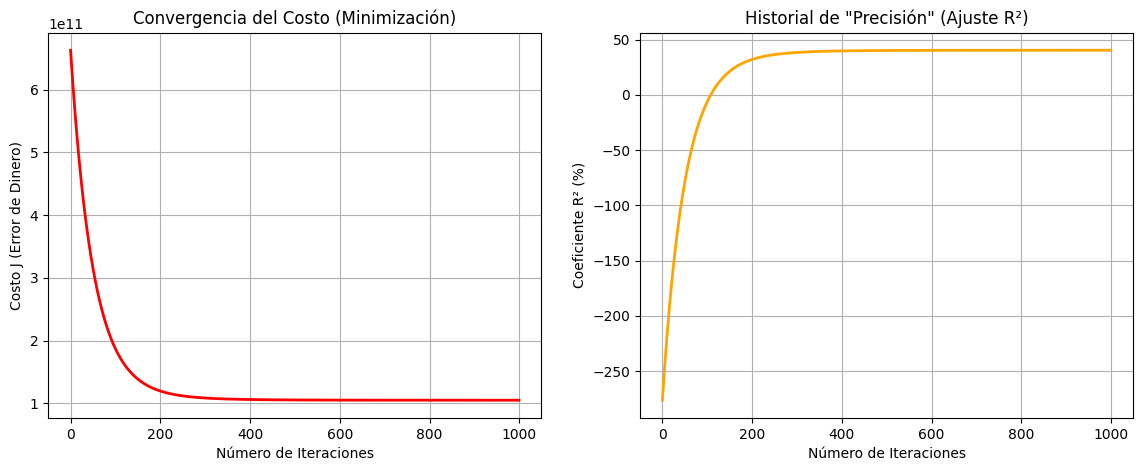

In [9]:
# Función de Costo
def calcularCosto(X, y, theta):
    m = len(y)
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

# Descenso por el Gradiente
def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    historial_J = []
    historial_R2 = [] # lista que guardara el porcentaje de "Precisión" (R2)

    # Calculamos la Varianza Total
    media_y = np.mean(y)
    suma_total_cuadrados = np.sum(np.square(y - media_y))

    for i in range(num_iters):
        # Calculamos la hipótesis y actualizamos theta
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))

        # Guardamos el Costo Histórico (J)
        historial_J.append(calcularCosto(X, y, theta))

        # Calculamos y guardamos el R-Cuadrado (R2) en porcentaje
        h_actual = np.dot(X, theta)
        suma_residuos_cuadrados = np.sum(np.square(h_actual - y))

        # Fórmula de R2
        r2 = 1 - (suma_residuos_cuadrados / suma_total_cuadrados)
        porcentaje_r2 = r2 * 100
        historial_R2.append(porcentaje_r2)

    return theta, historial_J, historial_R2

# Configuración y Entrenamiento
theta_inicial = np.zeros(X_listo.shape[1])
alpha = 0.01
iteraciones = 1000

print("Entrenando el modelo de predicción de precios...")
theta_optimizado, historial_J, historial_R2 = descensoGradiente(X_listo, y, theta_inicial, alpha, iteraciones)

print(f"\nCosto final minimizado: {historial_J[-1]:.4f}")
print(f"Coeficiente R2 final (Precisión del ajuste): {historial_R2[-1]:.2f}%")

# Gráfica de Convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Historial del Costo (Debe bajar)
ax1.plot(np.arange(len(historial_J)), historial_J, lw=2, color='red')
ax1.set_xlabel('Número de Iteraciones')
ax1.set_ylabel('Costo J (Error de Dinero)')
ax1.set_title('Convergencia del Costo (Minimización)')
ax1.grid(True)

# Gráfica 2: Historial del R2 (Debe subir hacia un porcentaje estable)
ax2.plot(np.arange(len(historial_R2)), historial_R2, lw=2, color='orange')
ax2.set_xlabel('Número de Iteraciones')
ax2.set_ylabel('Coeficiente R² (%)')
ax2.set_title('Historial de "Precisión" (Ajuste R²)')
ax2.grid(True)

plt.show()

## Ecuación de la Normal
Como método alternativo al Descenso por el Gradiente, calculamos los parámetros $\theta$ utilizando la **Ecuación de la Normal**.

**Justificación técnica:** La Ecuación de la Normal nos permite encontrar el valor óptimo de $\theta$ de forma analítica y en un solo paso matemático, utilizando la inversa de la matriz: $\theta = (X^T X)^{-1} X^T y$.
A diferencia del Descenso por el Gradiente, este método **no requiere normalizar los datos** (Feature Scaling) ni elegir una tasa de aprendizaje ($\alpha$). Sin embargo, es computacionalmente costoso si el número de características ($n$) es muy grande (generalmente $n > 10,000$), debido al costo de invertir la matriz. En nuestro caso, al tener $n=10$, es un método perfectamente viable y rápido.

In [10]:
# ECUACIÓN DE LA NORMAL

def ecuacionNormal(X, y):
    # Fórmula: theta = (X^T * X)^-1 * X^T * y
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

X_original_con_unos = np.concatenate([np.ones((m, 1)), X], axis=1)
theta_normal = ecuacionNormal(X_original_con_unos, y)

print("Valores de Theta (Ecuación de la Normal):")
print(theta_normal)

Valores de Theta (Ecuación de la Normal):
[-2.53908183e+06 -5.71744961e+02  2.62211214e+05 -1.62526670e+05
  4.06298244e+03  1.12316001e+03  6.56956643e+03  5.38583554e-02
 -4.29772495e+04 -5.47694631e+03]


## Predicción de Prueba
Para validar la eficacia del modelo, seleccionamos una casa de nuestro dataset (la primera fila) y comparamos el precio real con las predicciones generadas por ambos métodos matemáticos.

In [11]:
# PREDICCIÓN DE PRUEBA

print("PRUEBA DE PREDICCIÓN (Casa en la Fila 0)")
print("="*50)

precio_real = y[0]
prediccion_gd = np.dot(X_listo[0, :], theta_optimizado)
prediccion_normal = np.dot(X_original_con_unos[0, :], theta_normal)

print(f"Precio REAL de la casa:          ${precio_real:,.2f}")
print(f"Predicción (Gradiente):          ${prediccion_gd:,.2f}")
print(f"Predicción (Ecuación Normal):    ${prediccion_normal:,.2f}")

PRUEBA DE PREDICCIÓN (Casa en la Fila 0)
Precio REAL de la casa:          $1,490,000.00
Predicción (Gradiente):          $1,403,501.56
Predicción (Ecuación Normal):    $1,405,508.09
